# Ejercicio 5 — Wine Quality: covarianza, correlación y envejecimiento

---

> El dataset `wine_quality.xlsx` contiene información acerca del puntaje que un panel de enólogos asignó a una serie de 76 vinos de tipo Pinot Noir. Las cualidades evaluadas incluyeron algunas propiedades organolépticas como claridad (*clarity*), aroma (*aroma*), cuerpo (*body*) y sabor (*flavor*) y una valoración de la calidad general del vino (*quality*). Adicionalmente, se recabó información sobre el grado de envejecimiento (*aging*) de cada uno de los productos evaluados, la cual se encuentra en el dataset `wine_aging.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

---
## Ítem 1

> **Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los mismos que considere necesaria para su posterior análisis.**

In [2]:
# El Excel tiene 2 filas de metadatos antes de las cabeceras reales → header=2
wine = pd.read_excel('../Datasets/wine_quality.xlsx', header=2)

print('Columnas:', list(wine.columns))
print('Shape:', wine.shape)
wine.head()

Columnas: ['id', 'clarity', 'aroma', 'body', 'flavor', 'quality']
Shape: (77, 6)


,id,clarity,aroma,body,flavor,quality
0,1,1.0,3.3,2.8,3.1,9;8
1,2,1.0,4.4,4.9,3.5,12;6
2,3,1.0,3.9,5.3,4.8,11;9
3,4,1.0,3.9,2.6,3.1,11;1
4,4,1.0,3.9,2.6,3.1,11;1


In [3]:
# La columna 'quality' usa ';' como separador decimal (ej: '9;8' → 9.8)
wine['quality'] = wine['quality'].astype(str).str.replace(';', '.').astype(float)

# Eliminar filas duplicadas (hay un id duplicado en el Excel original)
wine = wine.drop_duplicates(subset='id').reset_index(drop=True)

print(f'Shape tras limpieza: {wine.shape}')
print(f'Valores faltantes:\n{wine.isnull().sum()}')
print(f'\nTipos de datos:\n{wine.dtypes}')
wine.describe().round(3)

Shape tras limpieza: (76, 6)
Valores faltantes:
id         0
clarity    0
aroma      0
body       0
flavor     0
quality    0
dtype: int64

Tipos de datos:
id           int64
clarity    float64
aroma      float64
body       float64
flavor     float64
quality    float64
dtype: object


,id,clarity,aroma,body,flavor,quality
count,76.000,76.000,76.000,76.000,76.000,76.000
mean,38.500,0.920,4.750,4.646,4.993,12.386
std,22.083,0.128,1.167,0.834,1.123,2.135
min,1.000,0.500,1.900,2.600,2.200,7.500
25%,19.750,0.800,4.000,4.000,4.275,11.275
50%,38.500,1.000,4.600,4.700,5.000,12.400
75%,57.250,1.000,5.500,5.325,5.800,13.500
max,76.000,1.200,8.300,6.600,7.900,18.600


In [4]:
aging = pd.read_csv('../Datasets/wine_aging.csv', sep=';')
print('aging shape:', aging.shape)
print('aging columnas:', list(aging.columns))
print(aging['aging'].unique())
aging.head()

aging shape: (76, 2)
aging columnas: ['WINE_id', 'aging']
<StringArray>
['crianza', 'reserva', 'gran reserva', 'granreserva', 'Reserva']
Length: 5, dtype: str


,WINE_id,aging
0,1,crianza
1,2,crianza
2,3,reserva
3,4,crianza
4,5,gran reserva


In [5]:
# Combinar wine_quality con wine_aging por el identificador de vino
df = wine.merge(aging, left_on='id', right_on='WINE_id', how='left')
df = df.drop(columns='WINE_id')   # columna redundante tras el merge

print(f'Shape combinado: {df.shape}')
print(f'Faltantes en aging: {df["aging"].isnull().sum()}')
df.head()

Shape combinado: (76, 7)
Faltantes en aging: 0


,id,clarity,aroma,body,flavor,quality,aging
0,1,1.0,3.3,2.8,3.1,9.8,crianza
1,2,1.0,4.4,4.9,3.5,12.6,crianza
2,3,1.0,3.9,5.3,4.8,11.9,reserva
3,4,1.0,3.9,2.6,3.1,11.1,crianza
4,5,1.0,5.6,5.1,5.5,13.3,gran reserva


---
## Ítem 2

> **¿Cuál es el tipo de vino (crianza/reserva/gran reserva) que presenta la mayor mediana para el sabor?**

In [6]:
mediana_flavor = df.groupby('aging')['flavor'].median().sort_values(ascending=False)
print('Mediana del sabor (flavor) por tipo de envejecimiento:')
print(mediana_flavor.round(3))
print(f"\nTipo con mayor mediana de sabor: '{mediana_flavor.idxmax()}' ({mediana_flavor.max():.3f})")

Mediana del sabor (flavor) por tipo de envejecimiento:
aging
granreserva     5.80
gran reserva    5.75
Reserva         5.00
reserva         4.80
crianza         3.40
Name: flavor, dtype: float64

Tipo con mayor mediana de sabor: 'granreserva' (5.800)


---
## Ítem 3

> **Construya la matriz de covariancia de las distintas variables cuantitativas que componen el dataset y comente qué tipo de información le aporta acerca de la relación entre los distintos pares de variables cuantitativas del dataset.**

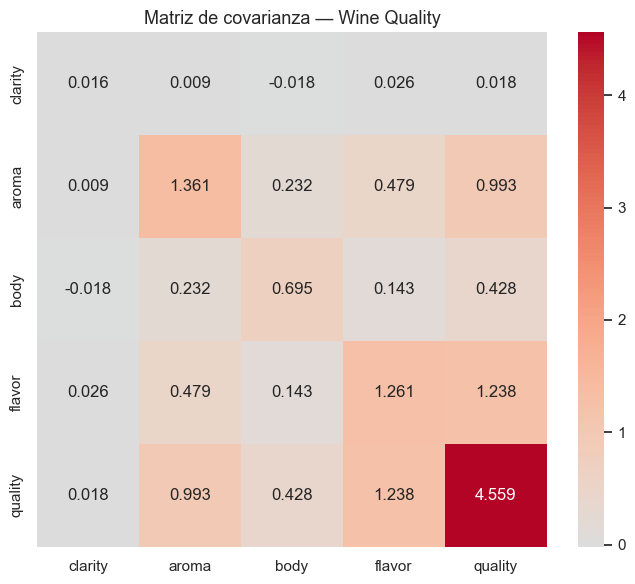

         clarity  aroma   body  flavor  quality
clarity    0.016  0.009 -0.018   0.026    0.018
aroma      0.009  1.361  0.232   0.479    0.993
body      -0.018  0.232  0.695   0.143    0.428
flavor     0.026  0.479  0.143   1.261    1.238
quality    0.018  0.993  0.428   1.238    4.559


In [7]:
# Variables cuantitativas: todas excepto 'id' y 'aging'
num_cols = ['clarity', 'aroma', 'body', 'flavor', 'quality']

cov_matrix = df[num_cols].cov()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cov_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Matriz de covarianza — Wine Quality', fontsize=13)
plt.tight_layout()
plt.show()

print(cov_matrix.round(3))

### Interpretación de la covarianza

La covarianza indica la **dirección** de la relación lineal entre cada par de variables:
- **Positiva**: ambas variables tienden a crecer juntas.
- **Negativa**: cuando una crece, la otra decrece.
- **Cercana a cero**: no hay relación lineal aparente.

Limitación: la magnitud depende de las unidades de cada variable, lo que **no permite comparar la intensidad** de la relación entre distintos pares. Para ello se usa la correlación.

---
## Ítem 4

> **Construya la matriz de correlación de las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente.**

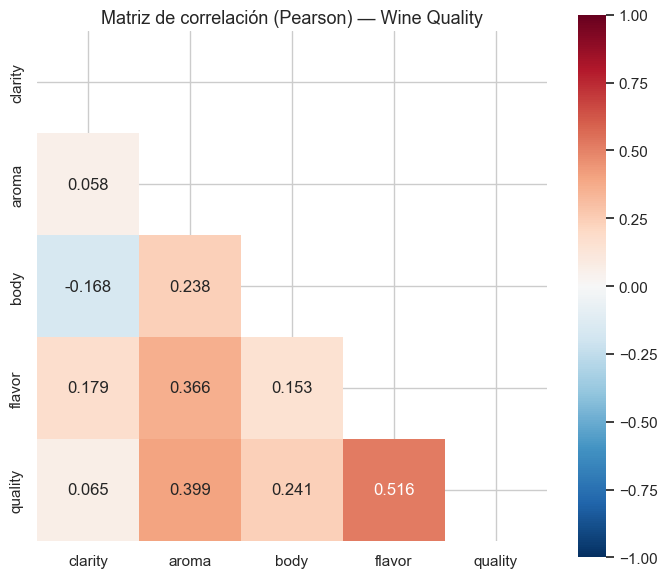

         clarity  aroma   body  flavor  quality
clarity    1.000  0.058 -0.168   0.179    0.065
aroma      0.058  1.000  0.238   0.366    0.399
body      -0.168  0.238  1.000   0.153    0.241
flavor     0.179  0.366  0.153   1.000    0.516
quality    0.065  0.399  0.241   0.516    1.000


In [8]:
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    square=True,
    ax=ax
)
ax.set_title('Matriz de correlación (Pearson) — Wine Quality', fontsize=13)
plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

In [9]:
# Identificar el par con mayor correlación (en valor absoluto), excluyendo la diagonal
pares = corr_matrix.abs().stack()
pares_unicos = pares[
    pares.index.get_level_values(0) != pares.index.get_level_values(1)
]
pares_unicos = pares_unicos[
    pares_unicos.index.map(lambda x: x[0] < x[1])
].sort_values(ascending=False)

print('Todos los pares ordenados por correlación absoluta:')
print(pares_unicos.round(3).to_string())

max_par = pares_unicos.idxmax()
corr_val = corr_matrix.loc[max_par[0], max_par[1]]

print(f'\nPar más correlacionado: {max_par[0]} — {max_par[1]}')
print(f'Coeficiente de Pearson: r = {corr_val:.4f}')

signo = 'positiva' if corr_val > 0 else 'negativa'
intensidad = 'muy fuerte' if abs(corr_val) > 0.9 else ('fuerte' if abs(corr_val) > 0.7 else 'moderada')
print(f'Interpretación: correlación lineal {signo} y {intensidad}.')

Todos los pares ordenados por correlación absoluta:
flavor   quality    0.516
aroma    quality    0.399
         flavor     0.366
body     quality    0.241
aroma    body       0.238
clarity  flavor     0.179
body     clarity    0.168
         flavor     0.153
clarity  quality    0.065
aroma    clarity    0.058

Par más correlacionado: flavor — quality
Coeficiente de Pearson: r = 0.5163
Interpretación: correlación lineal positiva y moderada.


---
## Ítem 5

> **Elija el par de variables que identificó en el ítem anterior como aquellas que se encuentran más fuertemente correlacionadas linealmente y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.**

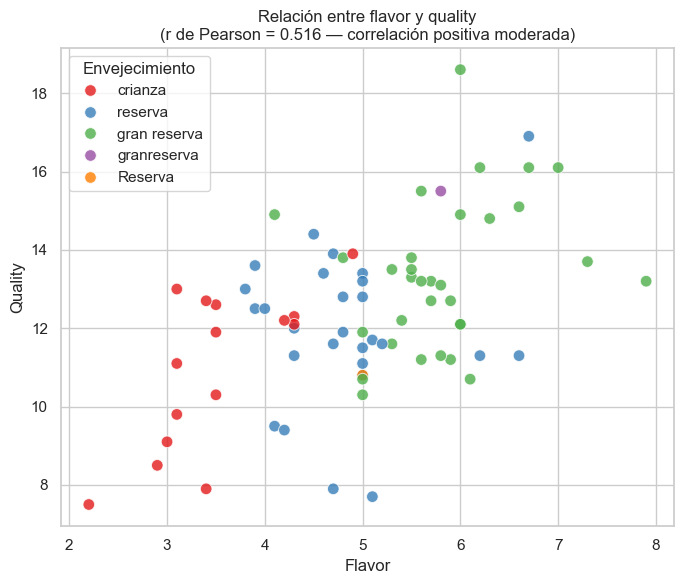

In [10]:
var1, var2 = max_par

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=df,
    x=var1,
    y=var2,
    hue='aging',
    palette='Set1',
    alpha=0.8,
    s=70,
    ax=ax
)
ax.set_title(
    f'Relación entre {var1} y {var2}\n'
    f'(r de Pearson = {corr_val:.3f} — correlación {signo} {intensidad})',
    fontsize=12
)
ax.set_xlabel(var1.capitalize())
ax.set_ylabel(var2.capitalize())
ax.legend(title='Envejecimiento')
plt.tight_layout()
plt.show()